In [235]:
import numpy as np
from matplotlib import pyplot as plt

# Run many time simulations

In [236]:
h_center = 3

#%run -i time_solver.py

# Continuation

In [237]:
import numpy as np
from matplotlib import pyplot as plt
def w(h):
    return (h**(-5)/5 + h**(-2)/2)
def dw(h):
    return (- h**(-6) + h**(-3))
def ddw(h):
    return (6*h**(-7) - 3*h**(-4))
# Continuation to compute h0in for different values of hmax or h0out
data = np.loadtxt(
    "continuation/1D_c0_continuation_nbc.txt",
    delimiter=',',
    unpack=True
)
numrows = len(data[0,:])
i_branch=28     # Stable branch begins here
K = data[i_branch:, numrows-1]
I = data[i_branch:, numrows-2]
Omega = data[i_branch:, numrows-3]
V = data[i_branch:, numrows-4]
H0out_formula = data[i_branch:, numrows-5]
H0out_lim = data[i_branch:, numrows-6]
Hmax = data[i_branch:, numrows-7]


# Validation for DISORDER
We take $c=0$ and $A=1+\epsilon x$

# Our formula
$$3 \eta h_{a}K v_{1}=-\partial_{\chi}A \hat{\Omega}+I(\partial_{\chi}A\partial_{H}\omega_0^{\mathrm{out}}+\partial_{\chi}H_{0}^{\mathrm{out}}A\partial_{HH}\omega_0^{\mathrm{out}})$$

Here we plot a different curve for each simulation as the value of the gradient of Hout is different in all simulations. However, all the curve are almost the same.

# Measure time simulations results

In [238]:
from pathlib import Path
import numpy as np
import re
from matplotlib import pyplot as plt


def analyze_simulation(directory):

    directory = Path(directory)

    results = []

    for filename in sorted(directory.glob("*.txt")):

        # Read header
        with open(filename, "r") as f:
            header = f.readline().strip()

        # Extract time from "@time=..."
        match = re.search(r"@time=([0-9.eE+-]+)", header)

        if match is None:
            print(f"Could not find time in {filename}")
            continue

        time = float(match.group(1))

        # Read x, y, h, p
        data = np.loadtxt(filename, comments="#")

        x = data[:, 0]
        h = data[:, 1]

        # Location of maximum h
        i = np.argmax(h)

        xmax = x[i]
        hmax = h[i]

        results.append([time, xmax, hmax])

    # Sort by time
    results = np.array(results)
    results = results[np.argsort(results[:, 0])]

    return results

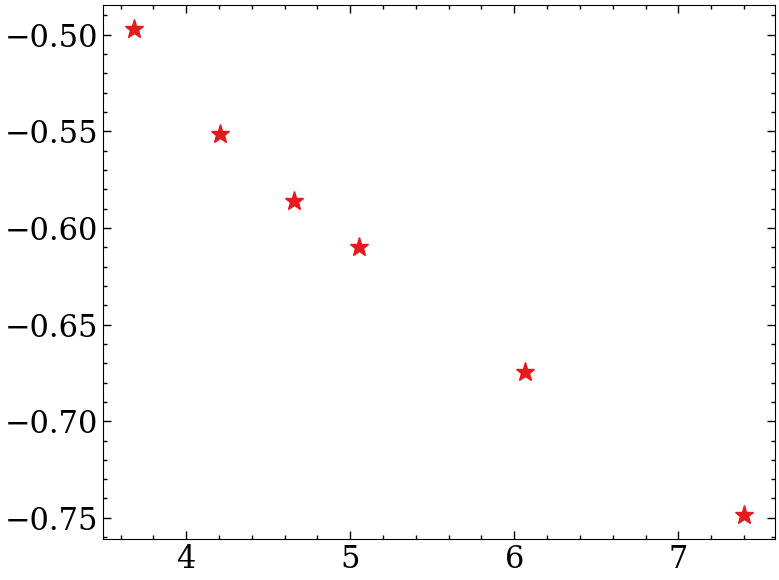

In [239]:
fig,ax = plt.subplots()
ha=0.5
eps=0.001

hcvec = [4,5,6,7,10,15]
hmax_vec = []
xdot_vec = []
grad_chi_vec = []
for hc in hcvec:
    # Read hmax(t)
    res=analyze_simulation(f"single_droplet_hcenter_{hc:g}_gradA=1/domain")
    hmax_ = res[-1,2]
    # Read xcm(t) and grad_chi h(t)
    data = np.loadtxt(f"single_droplet_hcenter_{hc:g}_gradA=1/obs_hcenter=_{hc:g}_gradA=1.txt", skiprows=1)
    t = data[:,0]
    xcm = data[:,3]/data[:,2]   # Numerator and denominator integrals are computed separately
    
    grad_chi_vec.append(ha**(-1)*data[-1,1])    # We need the gradient of capital H but in the simulations we measured gradh
    #plt.plot(t,xcm,'*')
    # Fit xdot from xcm(t)
    c=np.polyfit(t[-3:-1],xcm[-3:-1],deg=1)
    xdot_vec.append(c[0])
    hmax_vec.append(hmax_)

ax.plot(np.array(hmax_vec)/ha,ha*np.array(xdot_vec)/(eps),'*')
#plt.xlabel('hmax/ha')
#plt.ylabel('v1/ha^2')

# Pismen (2004) with continuation to compute the integrals
#plt.plot(hmax,V/(3*K))


# Use the formula with continuations results

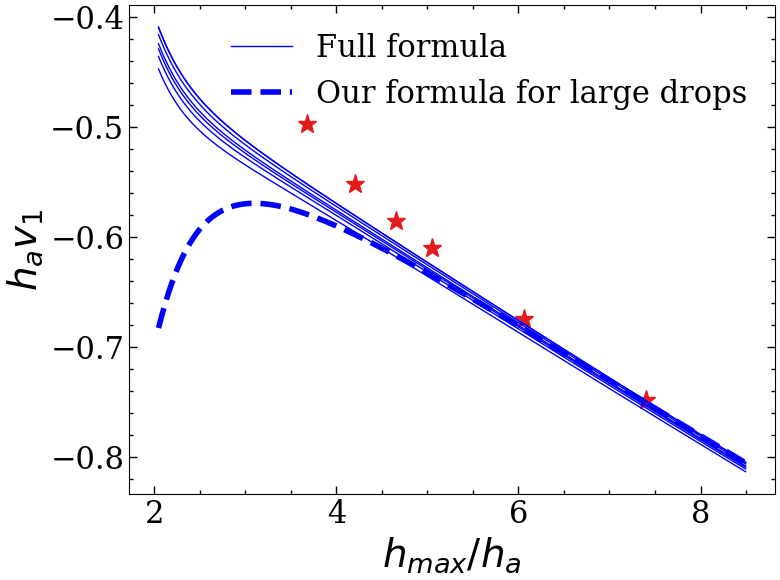

In [240]:
#fig,ax = plt.subplots()

# Full formula
for ghchi in grad_chi_vec:
    formula_noHout = (-Omega+I*dw(H0out_lim)+I*ghchi*ddw(H0out_lim))/(3*K)
    ax.plot(Hmax, formula_noHout,ls='-',color='blue',lw='1')
ax.plot(Hmax, formula_noHout,ls='-',color='blue',lw='1',label='Full formula')


# Our formula in the 'large drop limit'
formula_largedrop = -Omega/(3*K)
ax.plot(Hmax, formula_largedrop,'--',label='Our formula for large drops',color='blue')
#plt.plot(Hmax, (V-I+ha**(-3))/(3*K),'.-',label='Our formula for large drops')

ax.set_xlabel('$h_{max}/h_a$')
ax.set_ylabel('$h_a v_1$')
#plt.grid
ax.legend()
fig

# Droplet shape

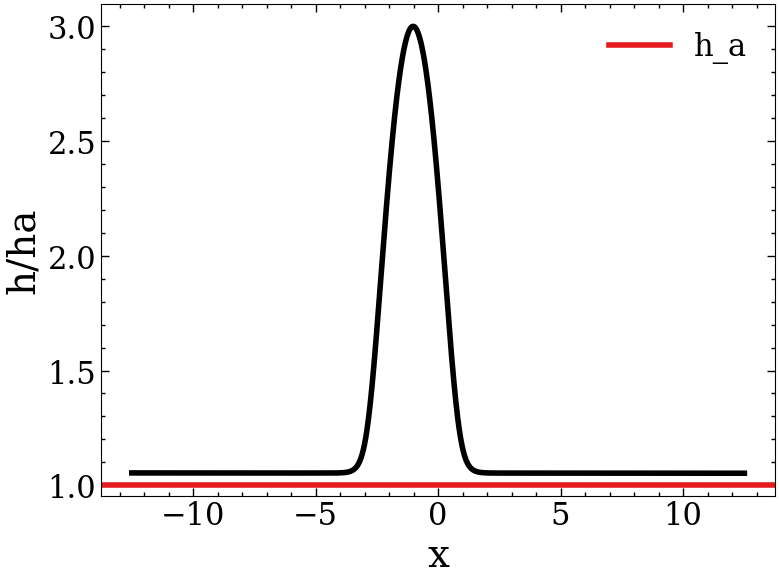

In [241]:
import numpy as np
from matplotlib import pyplot as plt
import matplotlib.tri as tri

data = np.loadtxt("single_droplet_hcenter_3_gradA=1/domain/domain_000010.txt", skiprows=1)

x = data[:,0]
h = data[:,1]
p = data[:,2]
plt.plot(x,h/ha,color='black')
#plt.ylim(min(h)-0.001,min(h)+0.001)
plt.xlabel('x')
plt.ylabel('h/ha')
plt.axhline(1,label='h_a')
plt.legend()

Text(0, 0.5, 'h/ha')

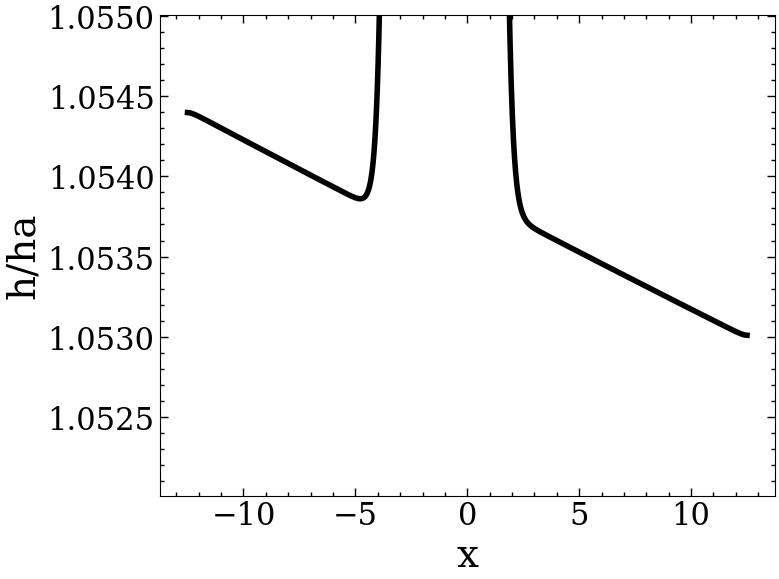

In [242]:
plt.plot(x,h/ha,color='black')
plt.ylim(min(h)/ha-0.001,min(h)/ha+0.002)
plt.xlabel('x')
plt.ylabel('h/ha')

# Validation for BULK FORCE
We consider that $A$ is homogeneous, while $W=Aw(h)-c\epsilon x$ with $c=1$

# Pismen (2004)

$$3\eta \theta^{-1}h_a^{-2} \mathbf{U}\epsilon^{-1} K_{\text{Pismen}}=c V$$
where 
$$K_{\text{Pismen}} = K+h_m^{-2}I$$
and $U/\epsilon = v_1$

# Our formula
$$3 \eta h_{a}^{-1}K v_{1}=c h_{a}V+I(-ch_{a}+\partial_{\chi}H_{0}^{\mathrm{out}}
A h_{a}^{-2}
\partial_{HH}\omega(H_{0}^{\mathrm{out}}))$$

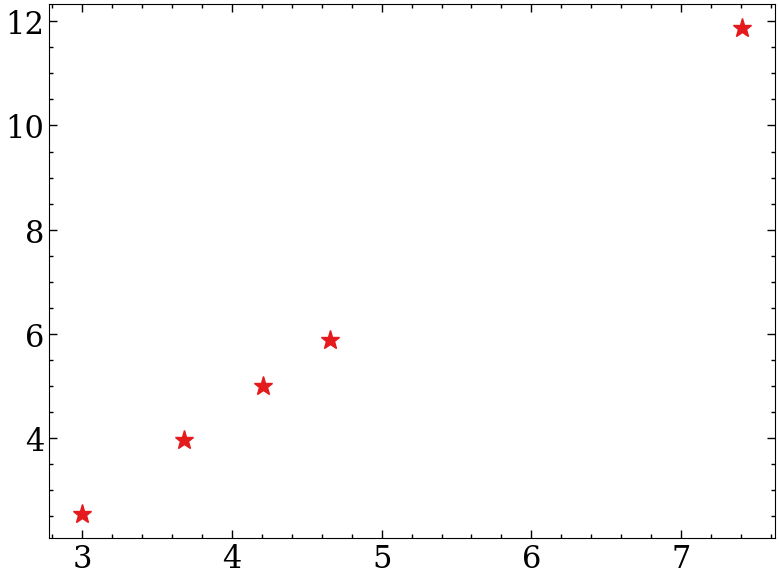

In [243]:
fig,ax = plt.subplots()
ha=0.5
eps=0.001

hcvec = [3,4,5,6,15]
hmax_vec = []
xdot_vec = []
grad_chi_vec = []
for hc in hcvec:
    # Read hmax(t)
    res=analyze_simulation(f"single_droplet_hcenter_{hc:g}_c=1/domain")
    hmax_ = res[-1,2]
    # Read xcm(t) and grad_chi h(t)
    data = np.loadtxt(f"single_droplet_hcenter_{hc:g}_c=1/obs_hcenter=_{hc:g}_c=1.txt", skiprows=1)
    t = data[:,0]
    xcm = data[:,3]/data[:,2]   # Numerator and denominator integrals are computed separately
    
    grad_chi_vec.append(ha**(-1)*data[-1,1])
    #plt.plot(t,xcm,'*')
    # Fit xdot from xcm(t)
    c=np.polyfit(t[-3:-1],xcm[-3:-1],deg=1)
    xdot_vec.append(c[0])
    hmax_vec.append(hmax_)

ax.plot(np.array(hmax_vec)/ha,np.array(xdot_vec)/(eps*ha**2),'*')
#plt.xlabel('hmax/ha')
#plt.ylabel('v1/ha^2')

# Pismen (2004) with continuation to compute the integrals
#plt.plot(hmax,V/(3*K))


# Use the formula with continuations results

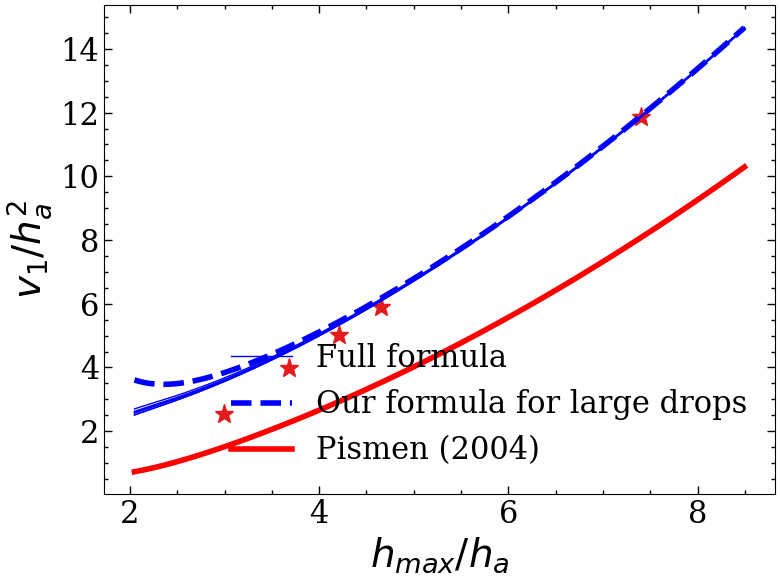

In [244]:
#fig,ax = plt.subplots()
# Full formula
for ghchi in grad_chi_vec:
    formula_noHout = (V-I+I*ghchi*ddw(H0out_lim)*ha**(-3))/(3*K)
    ax.plot(Hmax, formula_noHout,ls='-',color='blue',lw='1')
ax.plot(Hmax, formula_noHout,ls='-',color='blue',lw='1',label='Full formula')

# Our formula in the 'large drop limit'
formula_largedrop = V/(3*K)
ax.plot(Hmax, formula_largedrop,'--',label='Our formula for large drops',color='blue')
# Psimen (2004)
Kp = K+H0out_lim**(-2)*I
formula_Pismen = V/(3*Kp)
ax.plot(Hmax, formula_Pismen,'-',label='Pismen (2004)',color='red')

ax.set_xlabel('$h_{max}/h_a$')
ax.set_ylabel('$v_1/h_a^2$')
ax.legend()
fig

# Droplet shape

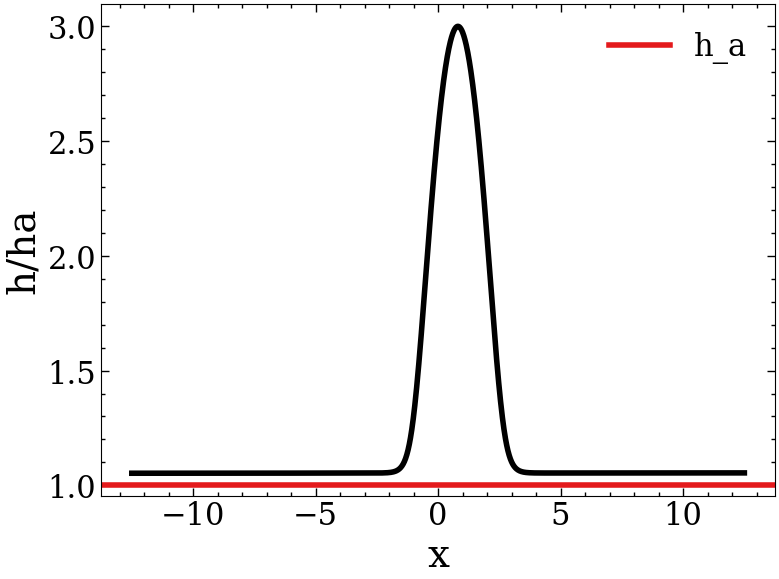

In [245]:
import numpy as np
from matplotlib import pyplot as plt
import matplotlib.tri as tri

data = np.loadtxt("single_droplet_hcenter_3_c=1/domain/domain_000009.txt", skiprows=1)

x = data[:,0]
h = data[:,1]
p = data[:,2]
plt.plot(x,h/ha,color='black')
#plt.ylim(min(h)-0.001,min(h)+0.001)
plt.xlabel('x')
plt.ylabel('h/ha')
plt.axhline(1,label='h_a')
plt.legend()

Text(0, 0.5, 'h/ha')

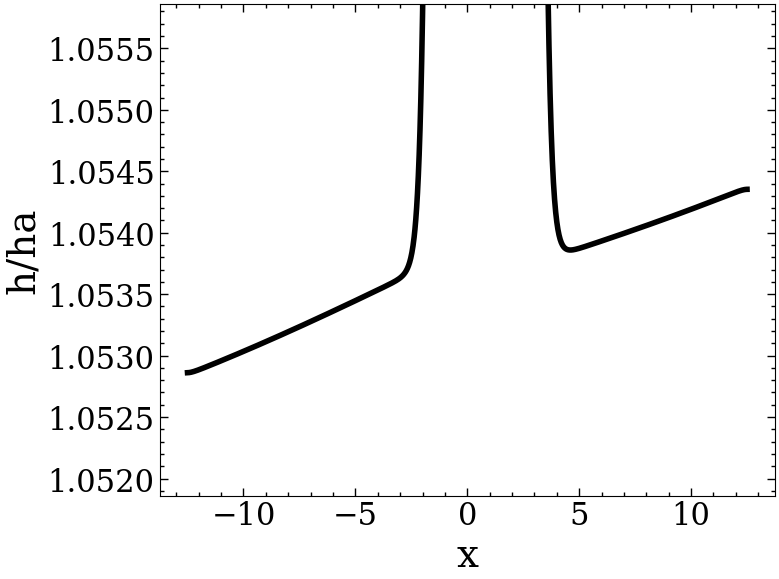

In [246]:
plt.plot(x,h/ha,color='black')
plt.ylim(min(h)/ha-0.001,min(h)/ha+0.003)
plt.xlabel('x')
plt.ylabel('h/ha')